# **TP6 - Interpretable Models (2)**

**Course: Advanced Programming For Data Science** <br>
**Lecturer: Dr. Sothea HAS** <br> 
**Mr. Vesal KHEAN**

-------

**Objective:**  Ensemble Learning Methods are about combining several base learners to enhance its performance. In this TP, you will apply each ensemble learning method on real datasets and analyze its sensitivity in terms of the key hyperparameters of the method.

- The `notebook` of this `TP` can be downloaded here: [TP6_Interpretable_Model2.ipynb](https://hassothea.github.io/Advanced-Machine-Learning-ITC/TPs/TP6_Interpretable_Model2.ipynb).

----------

## **1. Spam Email Dataset**

Email spam dataset contain `bag of words` of some real emails with its labels: `spam` and `nonspam`. Your job is to build interpretable email spam filter and report its average performance on new unseen emails.

In [1]:
import pandas as pd
path = "https://raw.githubusercontent.com/hassothea/MLcourses/main/data/spam.txt"
df = pd.read_csv(path, sep=" ")
df = df.drop(columns=['Id'])
df.head(2)

,make,address,all,num3d,our,over,remove,internet,order,mail,...,charSemicolon,charRoundbracket,charSquarebracket,charExclamation,charDollar,charHash,capitalAve,capitalLong,capitalTotal,type
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.0,0.00,...,0.0,0.000,0.0,0.778,0.00,0.000,3.756,61,278,spam
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.0,0.94,...,0.0,0.132,0.0,0.372,0.18,0.048,5.114,101,1028,spam


In [2]:
df.describe()

,make,address,all,num3d,our,over,remove,internet,order,mail,...,conference,charSemicolon,charRoundbracket,charSquarebracket,charExclamation,charDollar,charHash,capitalAve,capitalLong,capitalTotal
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.031869,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.285735,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,10.000000,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000


**A.** Inspect the dataset to find missing values and proportion of spam and nonspam emails.

In [3]:
df.isna().sum().to_frame().T.style

,make,address,all,num3d,our,over,remove,internet,order,mail,receive,will,people,report,addresses,free,business,email,you,credit,your,font,num000,money,hp,hpl,george,num650,lab,labs,telnet,num857,data,num415,num85,technology,num1999,parts,pm,direct,cs,meeting,original,project,re,edu,table,conference,charSemicolon,charRoundbracket,charSquarebracket,charExclamation,charDollar,charHash,capitalAve,capitalLong,capitalTotal,type
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


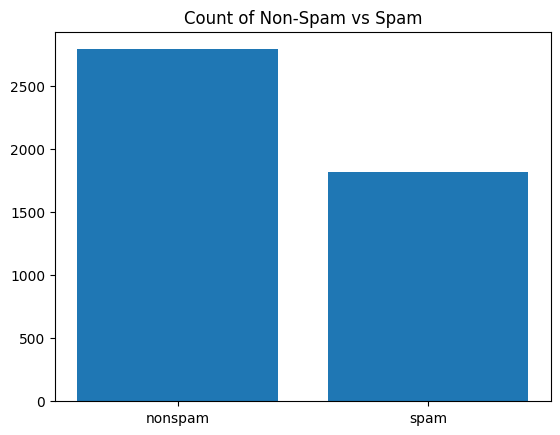

In [4]:
import matplotlib.pyplot as plt

typecount = df['type'].value_counts()

plt.bar(typecount.index, typecount.values)
plt.title('Count of Non-Spam vs Spam')
plt.show()

**B.** Identify columns with outliers. If decision tree classifier is used, would you handle the outliers.

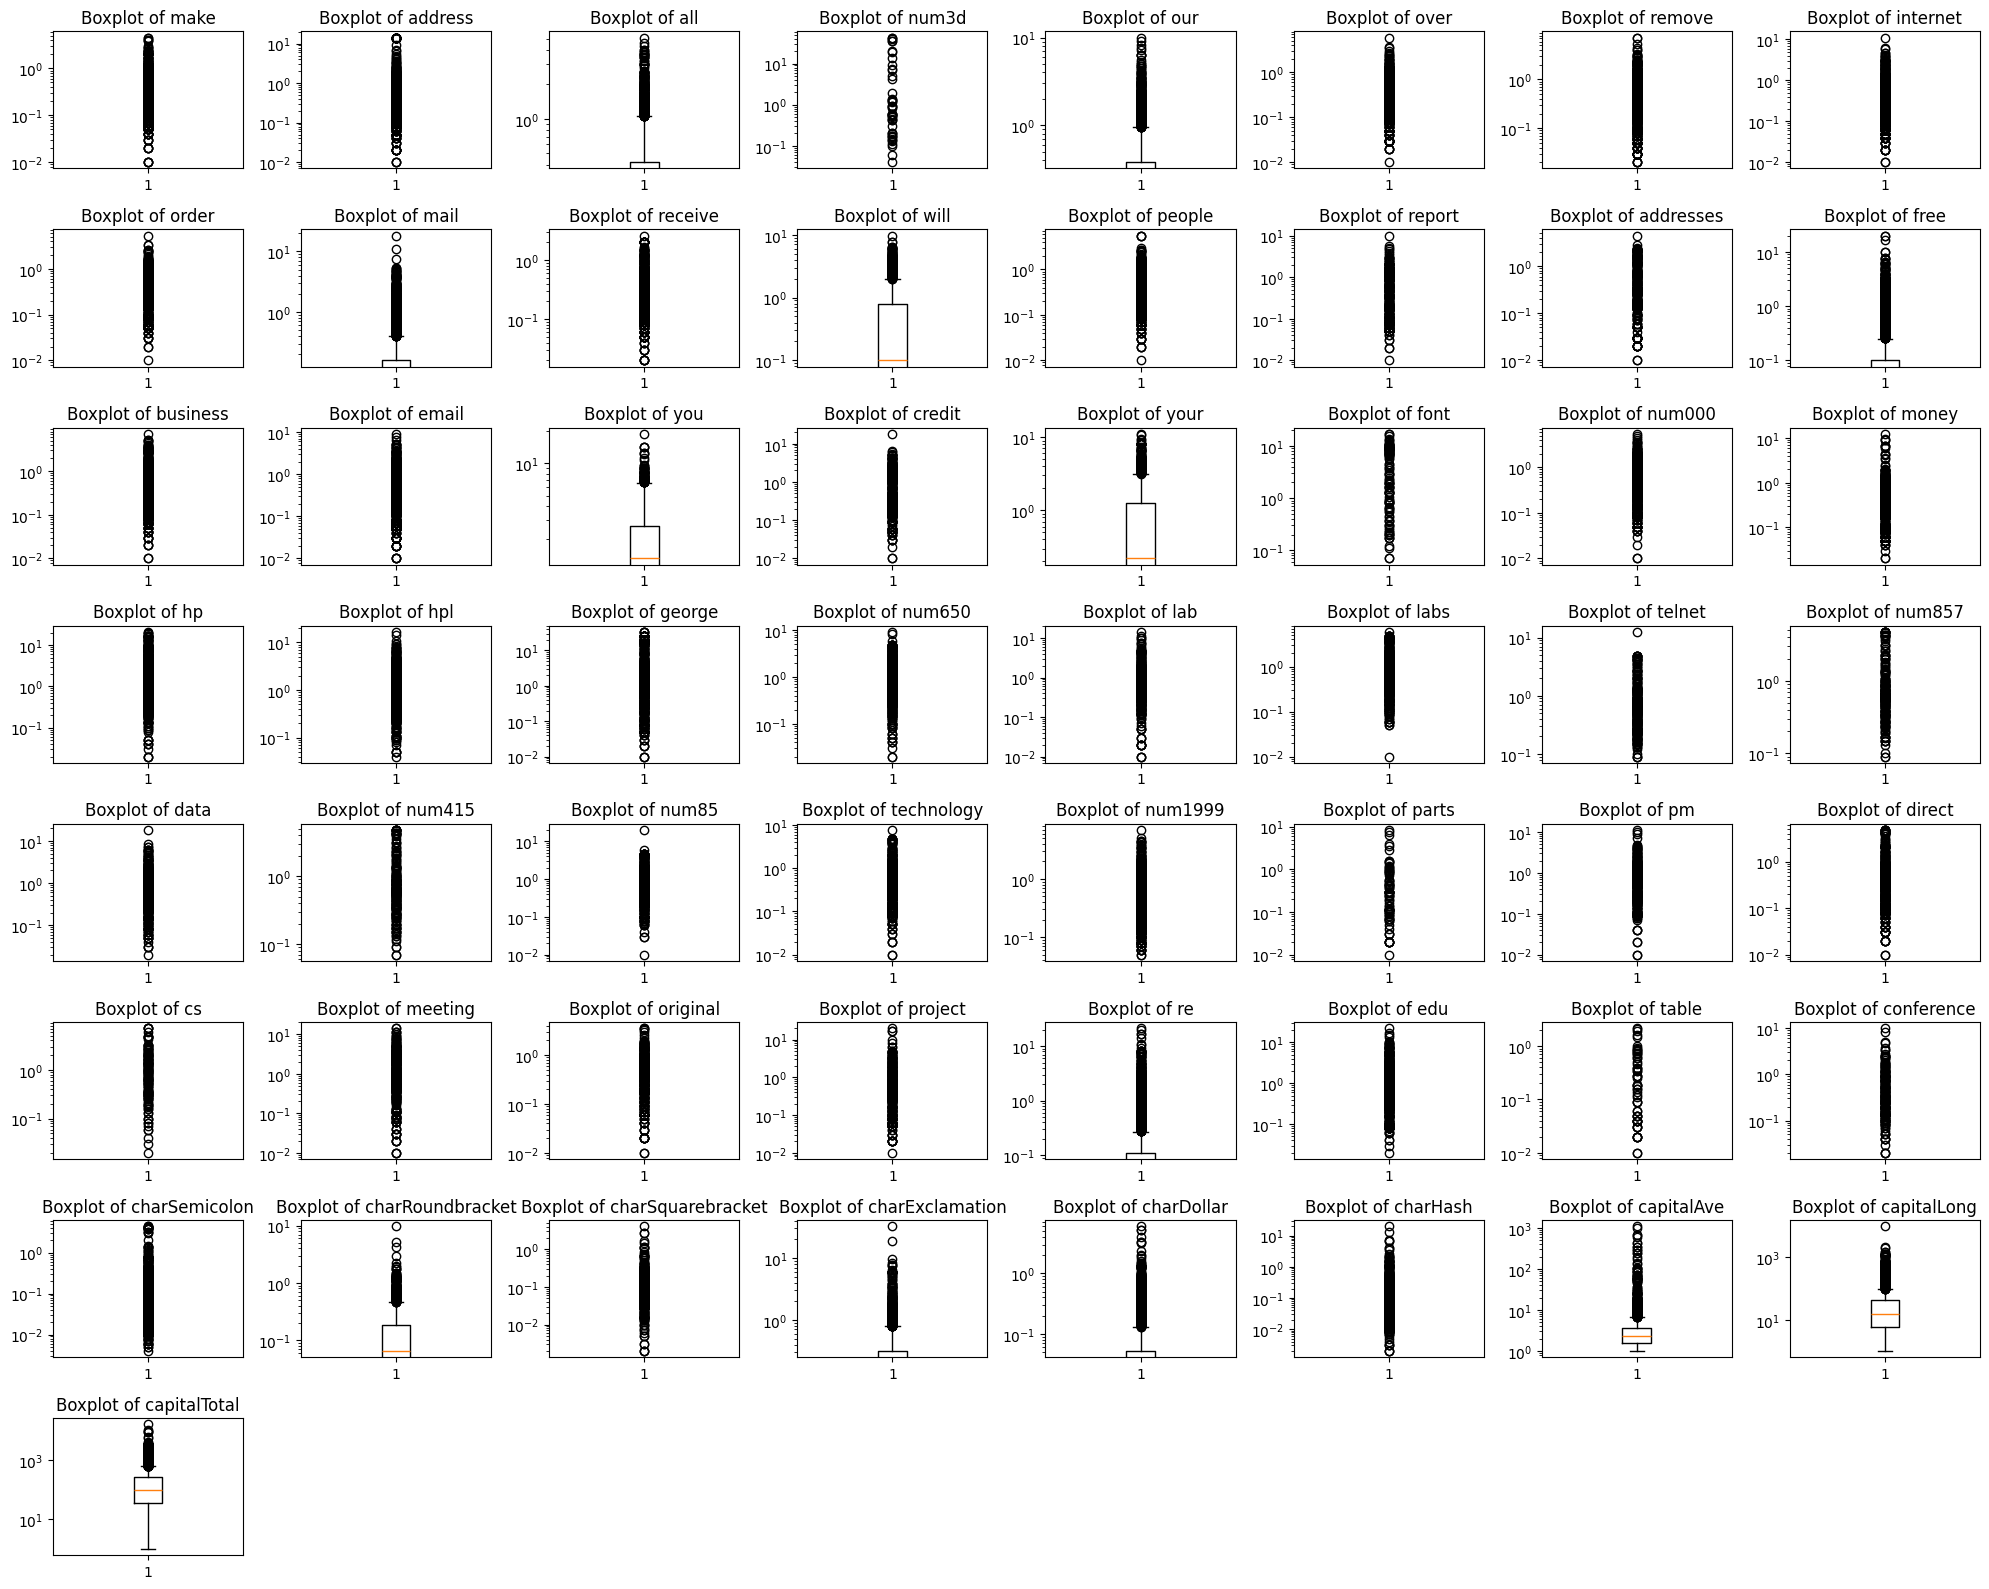

In [6]:
_, axes = plt.subplots(8, 8, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(df.select_dtypes(include='number').columns):
    axes[i].boxplot(df[col])
    axes[i].set_yscale('log')
    axes[i].set_title(f'Boxplot of {col}')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**C.** Check for the duplicated data. Drop them if there are any.

In [34]:
df.drop_duplicates(inplace=True)

**D.** Split the data into training and testing parts.

In [21]:
df['type'].unique()

array(['spam', 'nonspam'], dtype=object)

In [66]:
from sklearn.model_selection import train_test_split

X = df.drop(['type'], axis=1).values
y = df['type'].map({'spam' : 1, 'nonspam' : 0}).values

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify= y, test_size=0.3, random_state=82)

**E.** Fine-tune the hyperparameter of the selected models properly. 

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=82)

dt.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,82
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


**F.** Evaluate model performance on test data using suitable metrics: accuracy, recall, precision, f1 score.

In [68]:
from sklearn.metrics import classification_report
y_pred = dt.predict(X_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.93      0.90      0.92       785
           1       0.85      0.90      0.87       478

    accuracy                           0.90      1263
   macro avg       0.89      0.90      0.90      1263
weighted avg       0.90      0.90      0.90      1263



**G.** Interpret your resulting model:
    - Interpret the coefficient of logistic regression is used.
    - Breakdown the tree structure if a decision tree is used (`dtreeviz` module may be helpful).

In [ ]:
from dtreeviz import model

viz = model(
    dt, 
    X_train, 
    y_train,
    target_name='spam',
    feature_names=df.drop(['type'], axis=1).columns.tolist(),
    class_names=['nonspam', 'spam']
)

viz.view(fontname='monospace')


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x

<Figure size 640x480 with 0 Axes>

**H.** Save your best model.

## **2. Fashion MNIST Dataset**

Fashion-MNIST is a dataset of Zalando's article images—consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes. Zalando intends Fashion-MNIST to serve as a direct drop-in replacement for the original MNIST dataset for benchmarking machine learning algorithms. It shares the same image size and structure of training and testing splits.

The data is available here: [Fashion MNIST](https://www.kaggle.com/datasets/zalando-research/fashionmnist). Import the data.

**A.** Properly label and preprocess the data.

In [4]:
import pandas as pd

train_df = pd.read_csv('fashion-mnist_train.csv')
test_df = pd.read_csv('fashion-mnist_test.csv')

X_train = train_df.drop(columns=['label'])
y_train = train_df['label']

X_test = test_df.drop(columns=['label'])
y_test = test_df['label']

**B.** Apply default interpretable models to classify different items of the dataset.

**C.** Measure the model performance on the test dataset. Identify a few misclassified item.

**D.** Fine-tune the models. Measure its new performance.

**E.** Can you explain which pixels influences models prediction the most for a given item?

**F.** Save the model.

# References

$^{\text{📚}}$ [Bagging predictors, Breiman (1996)](https://link.springer.com/article/10.1007/BF00058655). <br>
$^{\text{📚}}$ [The strength of weak learnability, Robert E. Schapire (1990)](https://link.springer.com/article/10.1007/BF00116037). <br>
$^{\text{📚}}$ [COBRA: A combined regression strategy, Beau et al. (2016)](https://www.sciencedirect.com/science/article/pii/S0047259X15000950). <br>
$^{\text{📚}}$ [Gradient COBRA: A kernel-based consensual aggregation for regression, Has (2023)](https://doi.org/10.52933/jdssv.v3i2.70). <br>
$^{\text{📚}}$ [Aggregation using input–output trade-off, Fischer & Mougeot (2019)](https://www.sciencedirect.com/science/article/abs/pii/S0378375818302349). <br>
$^{\text{📚}}$ [Super Learner, M. J. Van der Laan (2007)](https://www.degruyter.com/document/doi/10.2202/1544-6115.1309/html). <br>